In [2]:
# Standard library
import warnings

# Data manipulation & visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

# Reproducibility — always set a random seed!
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Setup complete")

✅ Setup complete


In [3]:
df = pd.read_csv("../data/properties_database.csv")
df.head()

,province,type_property,property_id,subtype_property,postal_code,city,price,state_of_property,heating_type,sun_exposure,livable_surface,epc_score,latitude,longitude,facades,bedrooms,bathrooms,toilets,terrace,garden,garage,swimming_pool,flooding_area_type,distance_from_train_stations_by_foot,distance_from_elementary_school_by_foot,distance_from_high_school_by_foot
0,brussels,house,vbe35189,residence,1150,sint_pieters_woluwe,925000.000,to_be_renovated,fuel_oil,south_east,16.000,G,50.832,4.453,3,5.000,2,3,1,1,0,0,(information_not_available),4300.000,352.000,352.000
1,brussels,apartment,vbe35095,duplex,1000,brussels,395000.000,excellent,gas,not_specified,13.000,E,50.847,4.388,2,2.000,2,2,0,0,0,0,no_flooding_area,781.000,157.000,184.000
2,brussels,apartment,vbe35094,apartment,1210,sint_joost_ten_node,295000.000,normal,gas,not_specified,10.000,D,50.852,4.373,2,2.000,1,1,1,0,0,0,no_flooding_area,1100.000,173.000,237.000
3,brussels,apartment,vbe35040,apartment,1050,elsene,465000.000,fully_renovated,gas,not_specified,14.000,C,50.824,4.377,0,2.000,1,1,1,0,0,0,no_flooding_area,995.000,269.000,561.000
4,brussels,apartment,vbe34652,studio,1210,sint_joost_ten_node,150000.000,to_renovate,electricity,not_specified,34.000,F,50.851,4.374,2,0.000,1,0,1,0,0,0,(information_not_available),1200.000,197.000,133.000


In [121]:
# Basic cleaning of data

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Structural cleaning
 
    Steps:
    - drop redundant or not useful columns
    - drop duplicate listings (same property scraped under different IDs)
    - drop rows with price <= 0 or NaN values
    """

    df = df.copy()
    n_start = len(df)
 
    # Identifier and redundant columns
    cols_to_drop = {
        "property_id": "Unique identifier without predictive power",
        "city": "Location information to be retreived with lat/long",
        "postal_code": "Location information to be retreived with lat/long"
    }
    cols_present = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_present)
 
    # Duplicate listings: identical on every remaining column
    n_dupes = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"clean_data: dropped {n_dupes} duplicate rows")
 
    # Invalid / missing target
    invalid_price_mask = df["price"].isna() | (df["price"] <= 0)
    print(f"clean_data: dropped {invalid_price_mask.sum()} rows with invalid price")
    df = df.loc[~invalid_price_mask]
 
    print(f"clean_data: {n_start} -> {len(df)} rows")
    return df.reset_index(drop=True)

In [122]:
# EPC score transformation - NUMERICAL

"""
Brussels
Label A: ≤ 45 kWh/m²/year
Label B: 46–95 kWh/m²/year
Label C: 96–150 kWh/m²/year
Label D: 151–250 kWh/m²/year
Label E: 251–340 kWh/m²/year
Label F: 341–450 kWh/m²/year
Label G: > 450 kWh/m²/year
https://www.certinergie.be/en/energy-performance-certificate/epc-brussels/
"""

"""
Wallonia
Label A++: < 0 kWh/m²/year
Label A: ≤ 45 kWh/m²/year
Label A: ≤ 85 kWh/m²/year
Label B: 86–170 kWh/m²/year
Label C: 171–255 kWh/m²/year
Label D: 256–340 kWh/m²/year
Label E: 341–425 kWh/m²/year
Label F: 426–510 kWh/m²/year
Label G: > 510 kWh/m²/year
https://www.certinergie.be/en/energy-performance-certificate/epc-certificate-wallonia/
"""

"""
Flanders
Label A+: < 0 kWh/m²/year
Label A: 0-100 kWh/m²/year
Label B: 101-200 kWh/m²/year
Label C: 201-300 kWh/m²/year
Label D: 301-400 kWh/m²/year
Label E: 401-500 kWh/m²/year
Label F: > 500 kWh/m²/year
https://assets.vlaanderen.be/image/upload/v1706105167/VoorbeeldEPCvanafjanuari2019_nieuw_sg5wa0.pdf 
"""


def encode_epc_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encoding of EPC score. Each province's code system is different. 
    Here, the system takes the medium value of each label. 
    The info on the labels was extracted from official soruces.
    """

    #Identify each province with their region
    province_to_region ={ "brussels": "brussels", 
                         
                         "vlaams_brabant": "flanders", "antwerp": "flanders", "east_flanders": "flanders", 
                         "west_flanders": "flanders", "limburg": "flanders",

                         "brabant_wallon": "wallonia", "hainaut": "wallonia", "namur": "wallonia", 
                         "liege": "wallonia", "luxembourg": "wallonia"
    }

    # Use the middle value for each label according to official data 
    epc_to_kwh_by_region = {
        "brussels": {"A+": -22.5, "A": 22.5, "B": 70.5, "C": 123, "D": 200.5, "E": 295.5, "F": 395.5, "G": 504.5},
        "wallonia": {"A+": -22.5, "A": 65.5, "B": 128, "C": 213, "D": 298, "E": 383, "F": 468, "G": 552},
        "flanders": {"A+": -50, "A": 50, "B": 150.5, "C": 250.5, "D": 350.5, "E": 450.5, "F": 549.5, "G": 650}
    }

    df = df.copy()
    region = df["province"].str.strip().map(province_to_region)
    
    def check_kwh(label: str, reg: str) -> float:
        if pd.isna(label) or label == "not_specified" or pd.isna(reg):
            return np.nan
        return epc_to_kwh_by_region[reg].get(label, np.nan)
    
    df["epc_score_missing"] = (df["epc_score"] == "not_specified").astype(int)
    df["epc_kwh_m2_year"] = [
        check_kwh(label, reg) for label, reg in zip(df["epc_score"], region)
    ]
    df = df.drop(columns=["epc_score"])
    return df

In [123]:
# State of property - ORDINAL

def encode_property_state(df: pd.DataFrame) -> pd.DataFrame:
    """Ordinal encoding of property condition (0=worst to 4=best)."""

    state_of_property_mapping = {
        "to_demolish": 0,
        "to_be_renovated": 1, "to_renovate": 1, "to_restore": 1,
        "normal": 2,
        "excellent": 3, "fully_renovated": 3,
        "new": 4, "under_construction": 4
    }

    df = df.copy()
    df["state_of_property_missing"] = (df["state_of_property"] == "not_specified").astype(int)
    df["state_of_property_encoded"] = df["state_of_property"].map(state_of_property_mapping)
    df = df.drop(columns = ["state_of_property"])
    return df

In [124]:
# Categorical columns

def encode_onehot(df: pd.DataFrame, column: str, encoder: OneHotEncoder = None) -> tuple[pd.DataFrame, OneHotEncoder]:
    if encoder is None:
        encoder = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
        encoded = encoder.fit_transform(df[[column]])
    else:
        encoded = encoder.transform(df[[column]])

    encoded_df = pd.DataFrame(
        encoded,
        columns = encoder.get_feature_names_out([column]),
        index = df.index,
    )

    df = pd.concat([df, encoded_df], axis = 1)
    df = df.drop(columns = [column])
    return df, encoder


"""
Used to generalise the encode_onehot function above
def encode_province(df: pd.DataFrame) -> pd.DataFrame:

    encoder = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
    province_encoded = encoder.fit_transform(df[["province"]])

    province_df = pd.DataFrame(
        province_encoded,
        columns = encoder.get_feature_names_out(["province"]),
        index = df.index
    )
    df = pd.concat([df, province_df], axis = 1)
    df = df.drop(columns = ["province"])
    return df
"""

'\nUsed to generalise the encode_onehot function above\ndef encode_province(df: pd.DataFrame) -> pd.DataFrame:\n\n    encoder = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")\n    province_encoded = encoder.fit_transform(df[["province"]])\n\n    province_df = pd.DataFrame(\n        province_encoded,\n        columns = encoder.get_feature_names_out(["province"]),\n        index = df.index\n    )\n    df = pd.concat([df, province_df], axis = 1)\n    df = df.drop(columns = ["province"])\n    return df\n'

In [125]:
NOMINAL_COLUMNS = [
    "type_property",
    "subtype_property",
    "heating_type",
    "sun_exposure",
    "flooding_area_type",
    "province",
]

def preprocess_data(df: pd.DataFrame, encoders: dict = None) -> tuple[pd.DataFrame, dict]:
    df = encode_epc_score(df)
    df = encode_property_state(df)

    is_training = encoders is None
    if is_training:
        encoders = {}

    # --- Impute EPC kWh/m² ---
    if is_training:
        epc_median = df["epc_kwh_m2"].median()
        encoders["epc_median"] = epc_median
    else:
        epc_median = encoders["epc_median"]
    df["epc_kwh_m2"] = df["epc_kwh_m2"].fillna(epc_median)

    # --- Impute state_of_property_encoded ---
    if is_training:
        state_median = df["state_of_property_encoded"].median()
        encoders["state_median"] = state_median
    else:
        state_median = encoders["state_median"]
    df["state_of_property_encoded"] = df["state_of_property_encoded"].fillna(state_median)

    # --- One-hot encode nominal columns ---
    for col in NOMINAL_COLUMNS:
        df, fitted_encoder = encode_onehot(df, col, encoder=encoders.get(col))
        encoders[col] = fitted_encoder

    return df, encoders

In [126]:
# Splitting the dataset into train and test sets

df_cleaned = clean_data(df)


clean_data: dropped 138 duplicate rows
clean_data: dropped 0 rows with invalid price
clean_data: 9279 -> 9141 rows


In [127]:
# Splitting the dataset into train and test sets

def split_data(df: pd.DataFrame, test_size: float = 0.2, random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits the dataset into training and testing sets.
    
    Parameters:
    - df: The cleaned DataFrame to split.
    - test_size: Proportion of the dataset to include in the test split.
    - random_state: Seed used by the random number generator for reproducibility.
    
    Returns:
    - X_train: Training features.
    - X_test: Testing features.
    - y_train: Training target variable (price).
    - y_test: Testing target variable (price).
    """
    X = df.drop("price", axis=1)
    y = df["price"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(df_cleaned, test_size=0.2, random_state=42)

X_train_processed, fitted_encoders = preprocess_data(X_train)
X_test_processed, _ = preprocess_data(X_test, encoders=fitted_encoders)





KeyError: 'epc_kwh_m2'

In [ ]:
def scale_data(X_train_processed: pd.DataFrame, X_test_processed: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """
    Scales the training and testing feature sets using StandardScaler.
    
    Parameters:
    - X_train_processed: Preprocessed training features.
    - X_test_processed: Preprocessed testing features.
    
    Returns:
    - X_train_scaled: Scaled training features.
    - X_test_scaled: Scaled testing features.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_processed)
    X_test_scaled = scaler.transform(X_test_processed)
    
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = scale_data(X_train_processed, X_test_processed)

epc_kwh_m2_year              1200
state_of_property_encoded    1553
dtype: int64

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_model(X_train_scaled: np.ndarray, y_train: pd.Series):
    """
    Trains a regression model on the scaled training data.
    """
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    return model


def evaluate_model(model, X_test_scaled: np.ndarray, y_test: pd.Series) -> dict:
    """
    Evaluates the trained model on the test set.
    """
    y_pred = model.predict(X_test_scaled)
    
    return {
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": mean_squared_error(y_test, y_pred, squared=False),
        "r2": r2_score(y_test, y_pred),
    }

model = train_model(X_train_scaled, y_train)
metrics = evaluate_model(model, X_test_scaled, y_test)
print(metrics)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [13]:
# Debugging, making sure this version runs without errors.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Reproducibility — always set a random seed!
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def split_data(df: pd.DataFrame, test_size: float = 0.2, random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits the dataset into training and testing sets.
    
    Parameters:
    - df: The cleaned DataFrame to split.
    - test_size: Proportion of the dataset to include in the test split.
    - random_state: Seed used by the random number generator for reproducibility.
    
    Returns:
    - X_train: Training features.
    - X_test: Testing features.
    - y_train: Training target variable (price).
    - y_test: Testing target variable (price).
    """
    X = df.drop("price", axis=1)
    y = df["price"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    return X_train, X_test, y_train, y_test


def scale_data(X_train_processed: pd.DataFrame, X_test_processed: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """
    Scales the training and testing feature sets using StandardScaler.
    
    Parameters:
    - X_train_processed: Preprocessed training features.
    - X_test_processed: Preprocessed testing features.
    
    Returns:
    - X_train_scaled: Scaled training features.
    - X_test_scaled: Scaled testing features.
    - scaler: Fitted StandardScaler, for use on new data at inference time.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_processed)
    X_test_scaled = scaler.transform(X_test_processed)
    
    return X_train_scaled, X_test_scaled, scaler

def train_linear_regression(X_train_scaled: np.ndarray, y_train: pd.Series):
    """
    Trains a regression model on the scaled training data.
    """
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    return model


def evaluate_model(model, X_test_scaled: np.ndarray, y_test: pd.Series) -> dict:
    """
    Evaluates the trained model on the test set.
    """
    y_pred = model.predict(X_test_scaled)
    
    return {
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    }

# Basic cleaning of data
import pandas as pd


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Structural cleaning
 
    Steps:
    - drop redundant or not useful columns
    - drop duplicate listings (same property scraped under different IDs)
    - drop rows with price <= 0 or NaN values
    - drop top 5% most expensive properties (outlier trimming)
    - drop implausible cheap houses (misclassified properties, different payment structure, etc.)
    """

    df = df.copy()
    n_start = len(df)
 
    # Identifier and redundant columns
    cols_to_drop = {
        "property_id": "Unique identifier without predictive power",
        "city": "Location information to be retreived with lat/long",
        "postal_code": "Location information to be retreived with lat/long"
    }
    cols_present = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_present)
 
    # Duplicate listings: identical on every remaining column
    n_dupes = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"clean_data: dropped {n_dupes} duplicate rows")
 
    # Invalid / missing target
    invalid_price_mask = df["price"].isna() | (df["price"] <= 0)
    print(f"clean_data: dropped {invalid_price_mask.sum()} rows with invalid price")
    df = df.loc[~invalid_price_mask]

    # Drop top 5% most expensive properties (outlier trimming)
    price_cutoff = df["price"].quantile(0.95)
    expensive_mask = df["price"] > price_cutoff
    print(f"clean_data: dropped {expensive_mask.sum()} rows above 95th percentile price ({price_cutoff:,.0f})")
    df = df.loc[~expensive_mask]

    # Drop implausible cheap houses (misclassified properties, different payment structure, etc.)
    cheap_house_mask = (df["type_property"] == "house") & (df["price"] < 40000)
    print(f"clean_data: dropped {cheap_house_mask.sum()} houses priced below 40,000€")
    df = df.loc[~cheap_house_mask]

    #Final result
    print(f"Cleaning complete. {n_start} -> {len(df)} rows")

    return df.reset_index(drop=True)

from sklearn.preprocessing import OneHotEncoder

# List of nominal columns to be one-hot encoded. 
# Keeping this list here allows for easy modification in the future if needed.
NOMINAL_COLUMNS = [
    "type_property",
    "subtype_property",
    "heating_type",
    "sun_exposure",
    "flooding_area_type",
    "province"
]


def encode_epc_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encoding of EPC score. Each province's code system is different. 
    Here, the system takes the medium value of each label. 
    The info on the labels was extracted from official soruces.
    """

    """
    Some extra information on the EPC score and its meaning in each Belgian region:
    Brussels
    Label A: ≤ 45 kWh/m²/year
    Label B: 46–95 kWh/m²/year
    Label C: 96–150 kWh/m²/year
    Label D: 151–250 kWh/m²/year
    Label E: 251–340 kWh/m²/year
    Label F: 341–450 kWh/m²/year
    Label G: > 450 kWh/m²/year
    https://www.certinergie.be/en/energy-performance-certificate/epc-brussels/
    
    Wallonia
    Label A++: < 0 kWh/m²/year
    Label A: ≤ 45 kWh/m²/year
    Label A: ≤ 85 kWh/m²/year
    Label B: 86–170 kWh/m²/year
    Label C: 171–255 kWh/m²/year
    Label D: 256–340 kWh/m²/year
    Label E: 341–425 kWh/m²/year
    Label F: 426–510 kWh/m²/year
    Label G: > 510 kWh/m²/year
    https://www.certinergie.be/en/energy-performance-certificate/epc-certificate-wallonia/
 
    Flanders
    Label A+: < 0 kWh/m²/year
    Label A: 0-100 kWh/m²/year
    Label B: 101-200 kWh/m²/year
    Label C: 201-300 kWh/m²/year
    Label D: 301-400 kWh/m²/year
    Label E: 401-500 kWh/m²/year
    Label F: > 500 kWh/m²/year
    https://assets.vlaanderen.be/image/upload/v1706105167/VoorbeeldEPCvanafjanuari2019_nieuw_sg5wa0.pdf 
    """

    #Identify each province with their region
    province_to_region ={ "brussels": "brussels", 
                         
                         "vlaams_brabant": "flanders", "antwerp": "flanders", "east_flanders": "flanders", 
                         "west_flanders": "flanders", "limburg": "flanders",

                         "brabant_wallon": "wallonia", "hainaut": "wallonia", "namur": "wallonia", 
                         "liege": "wallonia", "luxembourg": "wallonia"
    }

    # Use the middle value for each label according to official data 
    epc_to_kwh_by_region = {
        "brussels": {"A+": -22.5, "A": 22.5, "B": 70.5, "C": 123, "D": 200.5, "E": 295.5, "F": 395.5, "G": 504.5},
        "wallonia": {"A+": -22.5, "A": 65.5, "B": 128, "C": 213, "D": 298, "E": 383, "F": 468, "G": 552},
        "flanders": {"A+": -50, "A": 50, "B": 150.5, "C": 250.5, "D": 350.5, "E": 450.5, "F": 549.5, "G": 650}
    }

    df = df.copy()
    region = df["province"].str.strip().map(province_to_region)
    
    def check_kwh(label: str, reg: str) -> float:
        if pd.isna(label) or label == "not_specified" or pd.isna(reg):
            return np.nan
        return epc_to_kwh_by_region[reg].get(label, np.nan)
    
    df["epc_score_missing"] = (df["epc_score"] == "not_specified").astype(int)
    df["epc_kwh_m2_year"] = [
        check_kwh(label, reg) for label, reg in zip(df["epc_score"], region)
    ]
    df = df.drop(columns=["epc_score"])
    return df


def encode_property_state(df: pd.DataFrame) -> pd.DataFrame:
    """Ordinal encoding of property condition (0=worst to 4=best)."""

    state_of_property_mapping = {
        "to_demolish": 0,
        "to_be_renovated": 1, "to_renovate": 1, "to_restore": 1,
        "normal": 2,
        "excellent": 3, "fully_renovated": 3,
        "new": 4, "under_construction": 4
    }

    df = df.copy()
    df["state_of_property_missing"] = (df["state_of_property"] == "not_specified").astype(int)
    df["state_of_property_encoded"] = df["state_of_property"].map(state_of_property_mapping)
    df = df.drop(columns = ["state_of_property"])
    return df

def encode_onehot(df: pd.DataFrame, column: str, encoder: OneHotEncoder = None) -> tuple[pd.DataFrame, OneHotEncoder]:
    if encoder is None:
        encoder = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")
        encoded = encoder.fit_transform(df[[column]])
    else:
        encoded = encoder.transform(df[[column]])

    encoded_df = pd.DataFrame(
        encoded,
        columns = encoder.get_feature_names_out([column]),
        index = df.index,
    )

    df = pd.concat([df, encoded_df], axis = 1)
    df = df.drop(columns = [column])
    return df, encoder

def preprocess_data(df: pd.DataFrame, encoders: dict = None) -> tuple[pd.DataFrame, dict]:
    df = encode_epc_score(df)
    df = encode_property_state(df)

    is_training = encoders is None
    if is_training:
        encoders = {}

    # --- Impute EPC kWh/m² ---
    if is_training:
        epc_median = df["epc_kwh_m2_year"].median()
        encoders["epc_median"] = epc_median
    else:
        epc_median = encoders["epc_median"]
    df["epc_kwh_m2_year"] = df["epc_kwh_m2_year"].fillna(epc_median)

    # --- Impute state_of_property_encoded ---
    if is_training:
        state_median = df["state_of_property_encoded"].median()
        encoders["state_median"] = state_median
    else:
        state_median = encoders["state_median"]
    df["state_of_property_encoded"] = df["state_of_property_encoded"].fillna(state_median)

    # --- One-hot encode nominal columns ---
    for col in NOMINAL_COLUMNS:
        df, fitted_encoder = encode_onehot(df, col, encoder=encoders.get(col))
        encoders[col] = fitted_encoder

    return df, encoders


# Reproducibility — always set a random seed!
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("../data/properties_database.csv")

df_cleaned = clean_data(df)

X_train, X_test, y_train, y_test = split_data(df_cleaned, test_size=0.2, random_state=42)

X_train_processed, fitted_encoders = preprocess_data(X_train)
X_test_processed, _ = preprocess_data(X_test, encoders=fitted_encoders)

X_train_scaled, X_test_scaled, fitted_scaler = scale_data(X_train_processed, X_test_processed)



#Random forest
from sklearn.model_selection import RandomizedSearchCV

from sklearn.tree import DecisionTreeRegressor

param_distributions = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20, 40],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'max_features': ['sqrt', 'log2', None]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

dt_search.fit(X_train_scaled, y_train)
best_dt = dt_search.best_estimator_

print("Best params:", dt_search.best_params_)
print("Best CV R²:", dt_search.best_score_)


clean_data: dropped 138 duplicate rows
clean_data: dropped 0 rows with invalid price
clean_data: dropped 455 rows above 95th percentile price (875,000)
clean_data: dropped 11 houses priced below 40,000€
Cleaning complete. 9279 -> 8675 rows
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'min_samples_split': 10, 'min_samples_leaf': 16, 'max_features': None, 'max_depth': None}
Best CV R²: 0.5183665953773272


In [6]:
# Hyperparameter tuning for Random Forest Regressor using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=50,              # number of random combinations to try
    cv=5,                   # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,               # use all CPU cores
    random_state=RANDOM_STATE,
    verbose=1
)

rf_search.fit(X_train_scaled, y_train)  # or X_train if RF doesn't need scaling

print("Best params:", rf_search.best_params_)
print("Best CV R²:", rf_search.best_score_)

best_rf = rf_search.best_estimator_  # ready to use for predictions

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
# XGBoost hyperparameter tuning using RandomizedSearchCV

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],       # L1 regularization
    'reg_lambda': [1, 1.5, 2]       # L2 regularization
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

xgb_search.fit(X_train_scaled, y_train)
best_xgb = xgb_search.best_estimator_

print("Best params:", xgb_search.best_params_)
print("Best CV R²:", xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_ 

Fitting 5 folds for each of 50 candidates, totalling 250 fits


ValueError: 
All the 250 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
250 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/guillermogallentlloria/Documents/BeCode/Git/immo-eliza-ml/.venv/lib/python3.14/site-packages/xgboost/data.py", line 402, in pandas_feature_info
    new_feature_types.append(_pandas_dtype_mapper[dtype.name])
                             ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'str'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/guillermogallentlloria/Documents/BeCode/Git/immo-eliza-ml/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~

In [16]:
from scipy import stats
import pandas as pd

target = 'price'
numeric_cols = df.select_dtypes(include='number').columns.drop(target)

results = []
for col in numeric_cols:
    valid = df[[col, target]].dropna()
    corr, p = stats.pearsonr(valid[col], valid[target])
    results.append({'feature': col, 'correlation': corr, 'p_value': p})

pval_df = pd.DataFrame(results).sort_values('p_value')
print(pval_df)

                                    feature  correlation        p_value
6                                 bathrooms     0.561118   0.000000e+00
5                                  bedrooms     0.447747   0.000000e+00
7                                   toilets     0.367226  3.469455e-294
11                            swimming_pool     0.351499  5.110572e-268
4                                   facades     0.251042  2.424584e-133
0                               postal_code    -0.213237   6.960644e-96
1                           livable_surface     0.205398   5.925919e-89
10                                   garage     0.199555   5.694170e-84
9                                    garden     0.196546   1.822830e-81
8                                   terrace     0.153221   7.475269e-50
2                                  latitude     0.126390   2.364683e-34
3                                 longitude    -0.057052   3.810120e-08
12     distance_from_train_stations_by_foot     0.047176   5.459

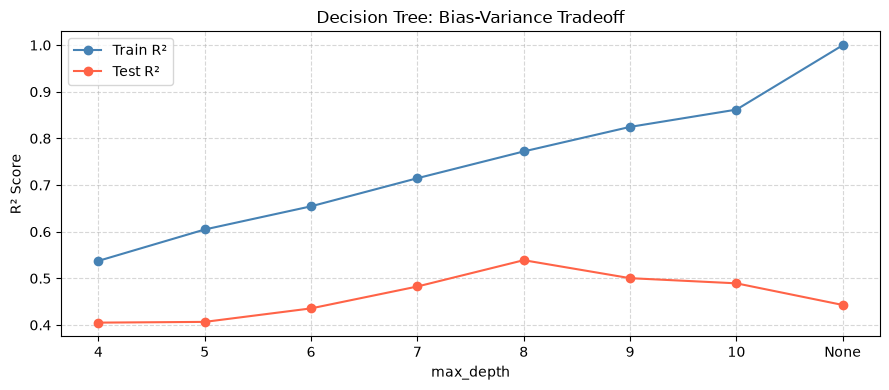

In [8]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

depths = [4, 5, 6, 7, 8, 9, 10, None]
train_scores, test_scores = [], []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

labels = [str(d) if d is not None else 'None' for d in depths]

plt.figure(figsize=(9, 4))
plt.plot(labels, train_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(labels, test_scores,  marker='o', label='Test R²',  color='tomato')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Decision Tree: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def decision_tree_regression(X_train_scaled: np.ndarray, y_train: pd.Series, max_depth: int = 3):
    """
    Trains a Decision Tree Regressor on the scaled training data.
    
    Parameters:
    - X_train_scaled: Scaled training features.
    - y_train: Training target variable (price).
    - max_depth: The maximum depth of the tree.
    
    Returns:
    - model: Trained Decision Tree Regressor model.
    """
    decision_tree = DecisionTreeRegressor(max_depth=max_depth, random_state=RANDOM_STATE)
    decision_tree.fit(X_train_scaled, y_train)
    print(f"Decision Tree — Train R²: {decision_tree.score(X_train_scaled, y_train):.4f}")
    

    return decision_tree

decision_tree = decision_tree_regression(X_train_scaled, y_train, max_depth=8)
print(f"Decision Tree — Test  R²: {decision_tree.score(X_test_scaled, y_test):.4f}")
evaluate_model(decision_tree, X_test_scaled, y_test)

"""Output:
Decision Tree — Train R²: 0.7720
Decision Tree — Test  R²: 0.5389

{'mae': 124204.9138697549,
 'rmse': 230500.40448426135,
 'r2': 0.5389098442153127}
"""

Decision Tree — Train R²: 0.7720
Decision Tree — Test  R²: 0.5389


{'mae': 124204.9138697549,
 'rmse': 230500.40448426135,
 'r2': 0.5389098442153127}

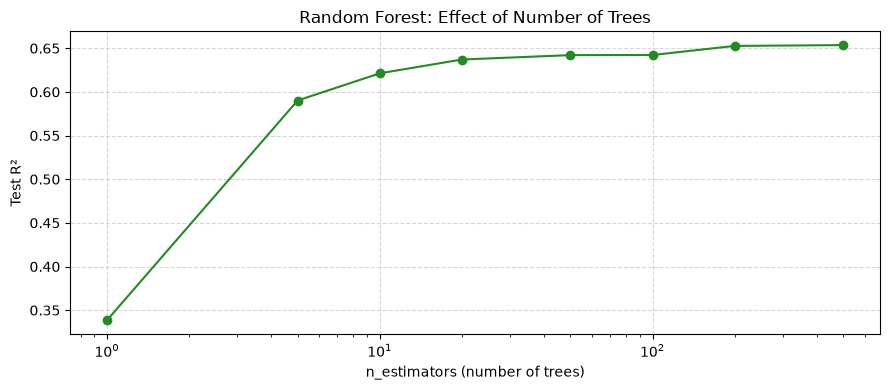

In [35]:
from sklearn.ensemble import RandomForestRegressor
n_trees = [1, 5, 10, 20, 50, 100, 200, 500]
rf_test_scores = []

for n in n_trees:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train_scaled, y_train)
    rf_test_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(9, 4))
plt.plot(n_trees, rf_test_scores, marker='o', color='forestgreen')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('Test R²')
plt.title('Random Forest: Effect of Number of Trees')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def random_forest_regression(X_train_scaled: np.ndarray, y_train: pd.Series, n_estimators: int = 200):
    """
    Trains a Random Forest Regressor on the scaled training data.
    
    Parameters:
    - X_train_scaled: Scaled training features.
    - y_train: Training target variable (price).
    - n_estimators: The number of trees in the forest.
    
    Returns:
    - model: Trained Random Forest Regressor model.
    """

    
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)
    print(f"Random Forest — Train R²: {model.score(X_train_scaled, y_train):.4f}")

    return model

random_forest = random_forest_regression(X_train_scaled, y_train, n_estimators=200)
print(f"Random Forest — Test  R²: {random_forest.score(X_test_scaled, y_test):.4f}")
rf_metrics = evaluate_model(random_forest, X_test_scaled, y_test)
print("Random Forest Detailed Metrics:", rf_metrics)



"""
With n_estimators = 100:
Random Forest — Train R²: 0.9537
Random Forest — Test  R²: 0.6423

With n_estimators = 200:
Random Forest — Train R²: 0.9541
Random Forest — Test  R²: 0.6527
Random Forest Detailed Metrics: {'mae': 98479.84569772711, 'rmse': 200055.3824955967, 'r2': 0.6526694790775537}
"""


Random Forest — Train R²: 0.9541
Random Forest — Test  R²: 0.6527
Random Forest Detailed Metrics: {'mae': 98479.84569772711, 'rmse': 200055.3824955967, 'r2': 0.6526694790775537}


'\nWith n_estimators = 100:\nRandom Forest — Train R²: 0.9537\nRandom Forest — Test  R²: 0.6423\n\nWith n_estimators = 200:\nRandom Forest — Train R²: 0.9541\nRandom Forest — Test  R²: 0.6527\n'

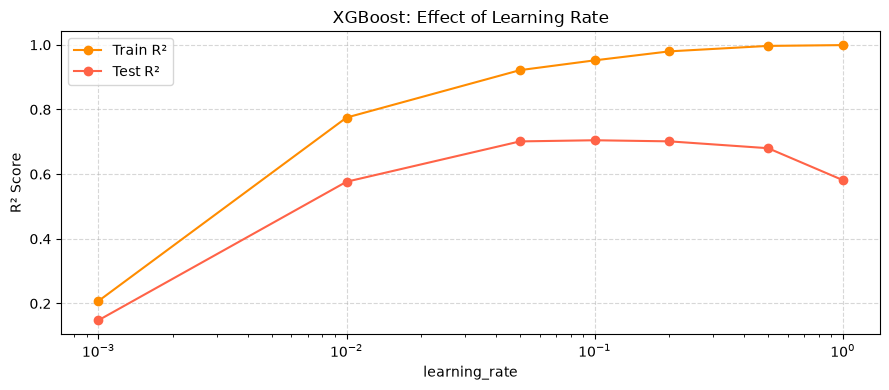

In [20]:
from xgboost import XGBRegressor

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
xgb_train_scores, xgb_test_scores = [], []

for lr in learning_rates:
    model = XGBRegressor(n_estimators=200, learning_rate=lr, random_state=42, verbosity=0)
    model.fit(X_train_scaled, y_train)
    xgb_train_scores.append(model.score(X_train_scaled, y_train))
    xgb_test_scores.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(9, 4))
plt.plot(learning_rates, xgb_train_scores, marker='o', label='Train R²', color='darkorange')
plt.plot(learning_rates, xgb_test_scores,  marker='o', label='Test R²',  color='tomato')
plt.xlabel('learning_rate')
plt.ylabel('R² Score')
plt.title('XGBoost: Effect of Learning Rate')
plt.xscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def xgboost_regression(X_train_scaled: np.ndarray, y_train: pd.Series, n_estimators: int = 100, max_depth: int = 6, learning_rate: float = 0.05):
    """
    Trains an XGBoost Regressor on the scaled training data.
    """
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_scaled, y_train)
    return model

xgboost = xgboost_regression(X_train_scaled, y_train, n_estimators=200, max_depth=6, learning_rate=0.05)
print(f"XGBoost — Train R²: {xgboost.score(X_train_scaled, y_train):.4f}")
print(f"XGBoost — Test  R²: {xgboost.score(X_test_scaled, y_test):.4f}")
xgb_metrics = evaluate_model(xgboost, X_test_scaled, y_test)
print("XGBoost Detailed Metrics:", xgb_metrics)

XGBoost — Train R²: 0.9217
XGBoost — Test  R²: 0.7013
XGBoost Detailed Metrics: {'mae': 92764.82361113484, 'rmse': 185530.07061511013, 'r2': 0.7012753325877196}


In [16]:
import joblib

joblib.dump(random_forest, "../models/random_forest.joblib")

['../models/random_forest.joblib']